In [16]:
import numpy as np
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import time

# ==========================================
# Global Hyperparameters
# ==========================================
SEED = 0
LR = 0.1
EPOCHS = 100
N_SAMPLES = 10000
X_TRAIN = np.linspace(-np.pi, np.pi, 10)

# Generate shared initial parameters for a fair comparison
np.random.seed(SEED)
SHARED_INIT_THETAS = np.random.uniform(0.1, 1.0, 2)


# =====================================================================
# PART 1: BATCHED MPS (REAL ISOMORPHISM) & STOCHASTIC PSR
# =====================================================================

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
f_dtype = torch.float32

# --- Real-Matrix Isomorphism for Quantum Gates ---
I_mps = torch.eye(4, dtype=f_dtype, device=device)

miX = torch.tensor([
    [ 0.,  0.,  0.,  1.],
    [ 0.,  0.,  1.,  0.],
    [ 0., -1.,  0.,  0.],
    [-1.,  0.,  0.,  0.]
], dtype=f_dtype, device=device)

miY = torch.tensor([
    [ 0., -1.,  0.,  0.],
    [ 1.,  0.,  0.,  0.],
    [ 0.,  0.,  0., -1.],
    [ 0.,  0.,  1.,  0.]
], dtype=f_dtype, device=device)

miZ = torch.tensor([
    [ 0.,  0.,  1.,  0.],
    [ 0.,  0.,  0., -1.],
    [-1.,  0.,  0.,  0.],
    [ 0.,  1.,  0.,  0.]
], dtype=f_dtype, device=device)

def rx_batched(theta):
    theta = torch.atleast_1d(torch.as_tensor(theta, device=device, dtype=f_dtype)).view(-1, 1, 1)
    return torch.cos(theta/2) * I_mps + torch.sin(theta/2) * miX

def ry_batched(theta):
    theta = torch.atleast_1d(torch.as_tensor(theta, device=device, dtype=f_dtype)).view(-1, 1, 1)
    return torch.cos(theta/2) * I_mps + torch.sin(theta/2) * miY

def rz_batched(theta):
    theta = torch.atleast_1d(torch.as_tensor(theta, device=device, dtype=f_dtype)).view(-1, 1, 1)
    return torch.cos(theta/2) * I_mps + torch.sin(theta/2) * miZ

# 原生 Ansatz: 估算 f(x)
def q_ansatz_L1_batched(x, thetas):
    x_t = torch.atleast_1d(torch.as_tensor(x, device=device, dtype=f_dtype))
    t0_t = torch.atleast_1d(torch.as_tensor(thetas[0], device=device, dtype=f_dtype))
    t1_t = torch.atleast_1d(torch.as_tensor(thetas[1], device=device, dtype=f_dtype))

    N = max(x_t.numel(), t0_t.numel(), t1_t.numel())

    state = torch.tensor([[1.], [0.], [0.], [0.]], dtype=f_dtype, device=device).expand(N, 4, 1)
    state = ry_batched(x_t) @ state
    state = rz_batched(t1_t) @ state
    state = rx_batched(t0_t) @ state

    prob_0 = state[:, 0, 0]**2 + state[:, 2, 0]**2
    outcomes = torch.where(torch.rand(N, device=device) < prob_0, 1.0, -1.0)
    return outcomes

# 【新增】Average Operator Ansatz: 估算 Af(x)
def q_ansatz_L1_batched_Af(x, thetas):
    x_t = torch.atleast_1d(torch.as_tensor(x, device=device, dtype=f_dtype))
    # 为 batch 中的每个样本生成随机符号：50% 是 1，50% 是 -1
    signs = torch.where(torch.rand(x_t.shape, device=device) < 0.5, 1.0, -1.0)
    x_flipped = x_t * signs
    # 将翻转后的 x 输入到原始的 ansatz 中
    return q_ansatz_L1_batched(x_flipped, thetas)

# --- 引入 ansatz_func 参数，使得同一个 PSR 函数可以处理 f(x) 和 Af(x) ---
def stochastic_psr_1st_x_mps(x, thetas, num_samples, ansatz_func=q_ansatz_L1_batched):
    s = np.pi / 2
    x_plus = torch.full((num_samples,), float(x) + s, device=device, dtype=f_dtype)
    x_minus = torch.full((num_samples,), float(x) - s, device=device, dtype=f_dtype)
    A_plus_est = ansatz_func(x_plus, thetas).mean()
    A_minus_est = ansatz_func(x_minus, thetas).mean()
    return 0.5 * (A_plus_est - A_minus_est).item()

def stochastic_psr_2nd_x_mps(x, thetas, num_samples, ansatz_func=q_ansatz_L1_batched):
    s = np.pi / 2
    G_plus = torch.tensor([2.0, -2.0], device=device)
    G_minus = torch.tensor([0.0, 0.0], device=device)

    idx_plus = torch.randint(0, 2, (num_samples,), device=device)
    idx_minus = torch.randint(0, 2, (num_samples,), device=device)

    x_plus = float(x) + G_plus[idx_plus] * s
    x_minus = float(x) + G_minus[idx_minus] * s

    A_plus_est = ansatz_func(x_plus, thetas).mean()
    A_minus_est = ansatz_func(x_minus, thetas).mean()
    return 0.5 * (A_plus_est - A_minus_est).item()

def psr_1st_theta_mps(x, thetas, target_idx, num_samples, ansatz_func=q_ansatz_L1_batched):
    s = np.pi / 2
    x_batch = torch.full((num_samples,), float(x), device=device, dtype=f_dtype)

    t_plus, t_minus = list(thetas), list(thetas)
    t_plus[target_idx] = float(thetas[target_idx]) + s
    t_minus[target_idx] = float(thetas[target_idx]) - s

    f_plus_est = ansatz_func(x_batch, t_plus).mean()
    f_minus_est = ansatz_func(x_batch, t_minus).mean()
    return 0.5 * (f_plus_est - f_minus_est).item()

def stochastic_psr_2nd_theta_mps(x, thetas, target_idx, num_samples, ansatz_func=q_ansatz_L1_batched):
    s = np.pi / 2
    G_plus = torch.tensor([[1.0, 1.0], [-1.0, -1.0]], device=device)
    G_minus = torch.tensor([[-1.0, 1.0], [1.0, -1.0]], device=device)

    idx_plus = torch.randint(0, 2, (num_samples,), device=device)
    idx_minus = torch.randint(0, 2, (num_samples,), device=device)

    shifts_plus = G_plus[idx_plus] * s
    shifts_minus = G_minus[idx_minus] * s

    x_plus = float(x) + shifts_plus[:, 0]
    x_minus = float(x) + shifts_minus[:, 0]

    t_plus, t_minus = list(thetas), list(thetas)
    t_plus[target_idx] = float(thetas[target_idx]) + shifts_plus[:, 1]
    t_minus[target_idx] = float(thetas[target_idx]) + shifts_minus[:, 1]

    A_plus_est = ansatz_func(x_plus, t_plus).mean()
    A_minus_est = ansatz_func(x_minus, t_minus).mean()
    return 0.5 * (A_plus_est - A_minus_est).item()

def stochastic_psr_3rd_theta_mps(x, thetas, target_idx, num_samples, ansatz_func=q_ansatz_L1_batched):
    s = np.pi / 2
    G_plus = torch.tensor([[2.0, 1.0], [-2.0, 1.0], [0.0, -1.0], [0.0, -1.0]], device=device)
    G_minus = torch.tensor([[2.0, -1.0], [-2.0, -1.0], [0.0, 1.0], [0.0, 1.0]], device=device)

    idx_plus = torch.randint(0, 4, (num_samples,), device=device)
    idx_minus = torch.randint(0, 4, (num_samples,), device=device)

    shifts_plus = G_plus[idx_plus] * s
    shifts_minus = G_minus[idx_minus] * s

    x_plus = float(x) + shifts_plus[:, 0]
    x_minus = float(x) + shifts_minus[:, 0]

    t_plus, t_minus = list(thetas), list(thetas)
    t_plus[target_idx] = float(thetas[target_idx]) + shifts_plus[:, 1]
    t_minus[target_idx] = float(thetas[target_idx]) + shifts_minus[:, 1]

    A_plus_est = ansatz_func(x_plus, t_plus).mean()
    A_minus_est = ansatz_func(x_minus, t_minus).mean()
    return 0.5 * (A_plus_est - A_minus_est).item()

# 原始 f(x) 训练循环
def train_batched_psr():
    print(f"\n--- Starting Batched PSR Training for f(x) on {device.type.upper()} ---")
    thetas = SHARED_INIT_THETAS.copy()
    loss_history = []
    start_time = time.time()

    for epoch in range(EPOCHS):
        grad_thetas = np.zeros(2)
        total_loss = 0.0

        for x in X_TRAIN:
            x_batch = torch.full((N_SAMPLES,), float(x), device=device, dtype=f_dtype)
            f_val = q_ansatz_L1_batched(x_batch, thetas).mean().item()
            f_x_val = stochastic_psr_1st_x_mps(x, thetas, N_SAMPLES)
            f_xx_val = stochastic_psr_2nd_x_mps(x, thetas, N_SAMPLES)

            res = f_xx_val + f_x_val + f_val - np.sin(x)
            total_loss += 0.5 * (res ** 2)

            for p_idx in range(2):
                d_f_theta = psr_1st_theta_mps(x, thetas, p_idx, N_SAMPLES)
                d_fx_theta = stochastic_psr_2nd_theta_mps(x, thetas, p_idx, N_SAMPLES)
                d_fxx_theta = stochastic_psr_3rd_theta_mps(x, thetas, p_idx, N_SAMPLES)

                grad_res = d_fxx_theta + d_fx_theta + d_f_theta
                grad_thetas[p_idx] += res * grad_res

        thetas -= LR * (grad_thetas / len(X_TRAIN))
        loss_mean = total_loss / len(X_TRAIN)
        loss_history.append(loss_mean)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:<3} | Loss: {loss_mean:.6f} | theta_0: {thetas[0]:.4f}, theta_1: {thetas[1]:.4f}")

    print(f"Time taken: {time.time() - start_time:.2f} seconds")
    return loss_history, thetas

# 【新增】 Af(x) 训练循环
def train_batched_psr_Af():
    print(f"\n--- Starting Batched PSR Training for Af(x) on {device.type.upper()} ---")
    thetas = SHARED_INIT_THETAS.copy()
    loss_history = []
    start_time = time.time()

    for epoch in range(EPOCHS):
        grad_thetas = np.zeros(2)
        total_loss = 0.0

        for x in X_TRAIN:
            x_batch = torch.full((N_SAMPLES,), float(x), device=device, dtype=f_dtype)

            # 使用包装过 Af(x) 的 ansatz
            f_val = q_ansatz_L1_batched_Af(x_batch, thetas).mean().item()
            f_x_val = stochastic_psr_1st_x_mps(x, thetas, N_SAMPLES, ansatz_func=q_ansatz_L1_batched_Af)
            f_xx_val = stochastic_psr_2nd_x_mps(x, thetas, N_SAMPLES, ansatz_func=q_ansatz_L1_batched_Af)

            res = f_xx_val + f_x_val + f_val - np.sin(x)
            total_loss += 0.5 * (res ** 2)

            for p_idx in range(2):
                d_f_theta = psr_1st_theta_mps(x, thetas, p_idx, N_SAMPLES, ansatz_func=q_ansatz_L1_batched_Af)
                d_fx_theta = stochastic_psr_2nd_theta_mps(x, thetas, p_idx, N_SAMPLES, ansatz_func=q_ansatz_L1_batched_Af)
                d_fxx_theta = stochastic_psr_3rd_theta_mps(x, thetas, p_idx, N_SAMPLES, ansatz_func=q_ansatz_L1_batched_Af)

                grad_res = d_fxx_theta + d_fx_theta + d_f_theta
                grad_thetas[p_idx] += res * grad_res

        thetas -= LR * (grad_thetas / len(X_TRAIN))
        loss_mean = total_loss / len(X_TRAIN)
        loss_history.append(loss_mean)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:<3} | Loss: {loss_mean:.6f} | theta_0: {thetas[0]:.4f}, theta_1: {thetas[1]:.4f}")

    print(f"Time taken: {time.time() - start_time:.2f} seconds")
    return loss_history, thetas


# =====================================================================
# PART 2: PYTORCH & AUTOMATIC DIFFERENTIATION IMPLEMENTATION (UNCHANGED)
# =====================================================================

I_th = torch.tensor([[1, 0], [0, 1]], dtype=torch.complex128)
X_th = torch.tensor([[0, 1], [1, 0]], dtype=torch.complex128)
Y_th = torch.tensor([[0, -1j], [1j, 0]], dtype=torch.complex128)
Z_th = torch.tensor([[1, 0], [0, -1]], dtype=torch.complex128)

def rx_th(theta):
    return torch.cos(theta/2) * I_th - 1j * torch.sin(theta/2) * X_th

def ry_th(theta):
    return torch.cos(theta/2) * I_th - 1j * torch.sin(theta/2) * Y_th

def rz_th(theta):
    return torch.cos(theta/2) * I_th - 1j * torch.sin(theta/2) * Z_th

def q_ansatz_L1_torch(x, thetas):
    state = torch.tensor([1, 0], dtype=torch.complex128)
    state = ry_th(x) @ state
    state = rx_th(thetas[0]) @ rz_th(thetas[1]) @ state
    exp_val = torch.vdot(state, Z_th @ state).real
    return exp_val

def train_pytorch_autodiff():
    print("\n--- Starting PyTorch + Autograd Training (CPU Baseline) ---")
    thetas = torch.nn.Parameter(torch.tensor(SHARED_INIT_THETAS, dtype=torch.float64))
    optimizer = optim.SGD([thetas], lr=LR)
    loss_history = []
    start_time = time.time()

    for epoch in range(EPOCHS):
        optimizer.zero_grad()
        total_loss = 0.0

        for x_val in X_TRAIN:
            x = torch.tensor([x_val], dtype=torch.float64, requires_grad=True)

            f_val = q_ansatz_L1_torch(x, thetas)
            f_x_val = torch.autograd.grad(f_val, x, create_graph=True)[0]
            f_xx_val = torch.autograd.grad(f_x_val, x, create_graph=True)[0]

            res = f_xx_val + f_x_val + f_val - torch.sin(x)
            loss = 0.5 * (res ** 2)
            total_loss = total_loss + loss

        mean_loss = total_loss / len(X_TRAIN)
        mean_loss.backward()
        optimizer.step()
        loss_history.append(mean_loss.item())

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:<3} | Loss: {mean_loss.item():.6f} | theta_0: {thetas[0].item():.4f}, theta_1: {thetas[1].item():.4f}")

    print(f"Time taken: {time.time() - start_time:.2f} seconds")
    return loss_history, thetas.detach().numpy()


# =====================================================================
# PART 3: EXECUTION AND PLOTTING
# =====================================================================
if __name__ == "__main__":
    print(f"Shared Initial parameters: theta_0 = {SHARED_INIT_THETAS[0]:.4f}, theta_1 = {SHARED_INIT_THETAS[1]:.4f}")
    print("Target parameters for f(x): theta_0 = pi, theta_1 = 0 \n")

    # Run all three models
    loss_np, final_thetas_np = train_batched_psr()
    loss_af, final_thetas_af = train_batched_psr_Af()
    loss_th, final_thetas_th = train_pytorch_autodiff()

    print("\n--- Final Results Comparison ---")

Shared Initial parameters: theta_0 = 0.5939, theta_1 = 0.7437
Target parameters for f(x): theta_0 = pi, theta_1 = 0 


--- Starting Batched PSR Training for f(x) on MPS ---
Epoch 10  | Loss: 0.617125 | theta_0: 1.0112, theta_1: 0.6114
Epoch 20  | Loss: 0.324730 | theta_0: 1.5200, theta_1: 0.4052
Epoch 30  | Loss: 0.126853 | theta_0: 1.9104, theta_1: 0.2437
Epoch 40  | Loss: 0.054246 | theta_0: 2.1448, theta_1: 0.1578
Epoch 50  | Loss: 0.030765 | theta_0: 2.2935, theta_1: 0.1102
Epoch 60  | Loss: 0.017503 | theta_0: 2.3951, theta_1: 0.0828
Epoch 70  | Loss: 0.011512 | theta_0: 2.4692, theta_1: 0.0651
Epoch 80  | Loss: 0.008407 | theta_0: 2.5255, theta_1: 0.0534
Epoch 90  | Loss: 0.006863 | theta_0: 2.5700, theta_1: 0.0449
Epoch 100 | Loss: 0.004928 | theta_0: 2.6055, theta_1: 0.0386
Time taken: 57.27 seconds

--- Starting Batched PSR Training for Af(x) on MPS ---
Epoch 10  | Loss: 0.492469 | theta_0: 1.1353, theta_1: 0.7440
Epoch 20  | Loss: 0.210969 | theta_0: 1.6514, theta_1: 0.7434
E

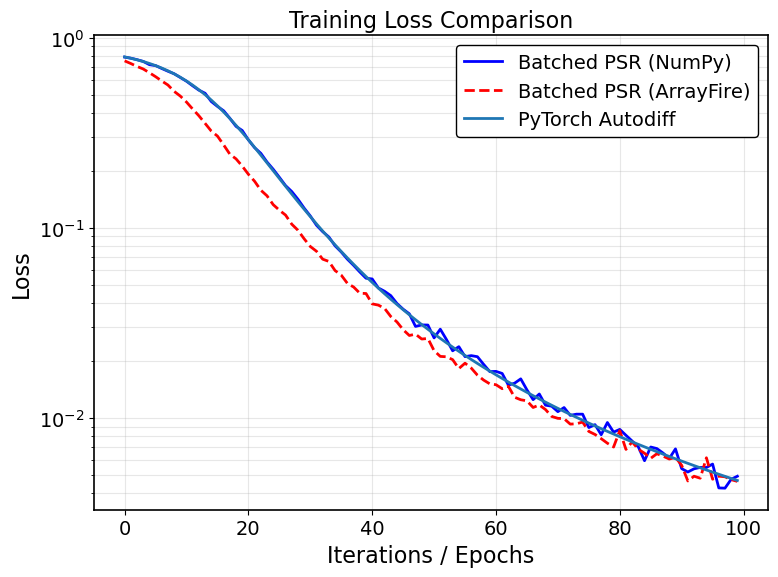

In [17]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# 1. 设置你要求的大字体和线宽风格
mpl.rcParams.update({
    "font.size": 14,          # 基础字体
    "axes.labelsize": 16,     # x, y 轴标题
    "axes.titlesize": 16,     # 图表标题
    "xtick.labelsize": 14,    # x 轴刻度标签
    "ytick.labelsize": 14,    # y 轴刻度标签
    "legend.fontsize": 14,    # 图例字体
    "axes.linewidth": 1.2,    # 坐标轴线宽
})

# 创建画布，设置一个合适的比例
plt.figure(figsize=(8, 6))

# 2. 绘制三条 Loss 曲线
# 这里使用了不同的线型 (linestyle) 和较粗的线宽 (linewidth) 以增加区分度和可读性
plt.plot(loss_np, label="Batched PSR (NumPy)", color='blue', linewidth=2, linestyle='-')
plt.plot(loss_af, label="Batched PSR (ArrayFire)", color='red', linestyle='--', linewidth=2)
plt.plot(loss_th, label="PyTorch Autodiff", linewidth=2)

# 3. Y轴使用对数坐标
plt.yscale("log")

# 4. 设置坐标轴标签和标题（针对 Loss 比较进行了调整）
plt.xlabel("Iterations / Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")

# 5. 设置网格、图例和布局
plt.grid(True, which="both", alpha=0.3)
plt.legend(
    loc="upper right",  # 如果曲线经常挡住左上角，可以改为 "upper right" 或 "best"
    framealpha=1.0,
    facecolor="white",
    edgecolor="black"
)

# 紧凑布局并显示
plt.tight_layout()
plt.show()